# Chapter 7: Domain Features as Testable Hypotheses

**How much does an entity-history feature add over the raw amount when the key merges several customers, and how much of its apparent value comes from rows the prediction could not see?**

The chapter's fraud example turns on an entity the data does not name. A pseudo-ID built from descriptors can merge unrelated customers, and a whole-period mean can read future behavior. Measuring both shows when the history is worth building and when its development score stops describing the deployed model.

*Constructed data; the spend-level spread, the 3 times fraud multiple and the random merging are properties of this generator, not measurements from a fraud competition.*

## The experiment

A constructed log of 400 customers with 6 to 14 transactions each (about 4,000 rows, 6% fraud). Customers differ widely in typical spend, and a fraudulent amount is 3 times the customer's own level, so the raw amount is a weak signal and the amount relative to the customer's history is a strong one. The model sees only a pseudo-ID key shared by the number of customers set by the control. Three feature sets feed a histogram gradient boosting classifier: the raw amount, the raw amount plus the log ratio to the past-only mean of the key, and the raw amount plus the log ratio to a whole-period mean (every development row of the key, including later ones). Each is scored by AUC two ways: 5-fold cross-validation on the first 70% of time, and a forward holdout on the last 30%, where only history up to the current row exists. Every score is the mean over 8 constructed logs.

In [1]:
import numpy as np
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

from kaggle_companion.activities._common import clean

SEED = 7
REPLICATES = 8        # independent constructed transaction logs; every score is their mean
N_CUSTOMERS = 400
CUTOFF = 0.7          # transactions before this time are development rows, the rest are the forward holdout
FRAUD_RATE, FRAUD_MULTIPLE = 0.06, 3.0


def generate(per_key, seed):
    """One transaction log sorted by time. Customers differ a lot in spend level; fraud is 3x the customer's own level.
    The pipeline never sees the customer, only a pseudo-ID key shared by `per_key` customers chosen at random."""
    rng = np.random.default_rng(seed)
    level = np.exp(rng.normal(3.5, 1.2, N_CUSTOMERS))           # each customer's typical amount
    customer = np.repeat(np.arange(N_CUSTOMERS), rng.integers(6, 15, N_CUSTOMERS))
    time = rng.random(len(customer))
    fraud = (rng.random(len(customer)) < FRAUD_RATE).astype(int)
    amount = level[customer] * np.exp(rng.normal(0, 0.5, len(customer)) + fraud * np.log(FRAUD_MULTIPLE))
    key = (rng.permutation(N_CUSTOMERS) // per_key)[customer]   # per_key = 1 is a perfect entity ID
    order = np.argsort(time, kind="stable")
    return time[order], key[order], amount[order], fraud[order]


def history_means(time, key, amount):
    """Two entity means for every row. Past-only: earlier rows of the same key. Whole-period: every development
    row of the key (past, present and future) for development rows; rows seen up to now for holdout rows."""
    n = len(amount)
    dev = time < CUTOFF
    past, to_date = np.full(n, np.nan), np.empty(n)
    total, count = {}, {}
    for i in range(n):                                          # rows are in time order
        s, c = total.get(key[i], 0.0), count.get(key[i], 0)
        past[i] = s / c if c else np.nan                        # the first row of a key has no history
        total[key[i]], count[key[i]] = s + amount[i], c + 1
        to_date[i] = total[key[i]] / count[key[i]]              # includes the current row, no future
    dev_total, dev_count = {}, {}
    for i in np.where(dev)[0]:
        dev_total[key[i]] = dev_total.get(key[i], 0.0) + amount[i]
        dev_count[key[i]] = dev_count.get(key[i], 0) + 1
    whole = np.array([dev_total[key[i]] / dev_count[key[i]] if dev[i] else to_date[i] for i in range(n)])
    return dev, past, whole


def columns(amount, mean):
    """log(amount / mean) plus a flag for rows with no history (ratio set to 0 there)."""
    missing = np.isnan(mean)
    ratio = np.where(missing, 0.0, np.log(amount) - np.log(np.where(missing, 1.0, mean)))
    return [ratio, missing.astype(float)]


def model():
    return HistGradientBoostingClassifier(max_iter=80, learning_rate=0.1, max_depth=3, random_state=0)


def one_log(per_key, seed):
    time, key, amount, y = generate(per_key, seed)
    dev, past, whole = history_means(time, key, amount)
    sets = {"raw": [np.log(amount)],
            "past_only": [np.log(amount)] + columns(amount, past),
            "whole_period": [np.log(amount)] + columns(amount, whole)}
    out = {}
    for name, cols in sets.items():
        X = np.column_stack(cols)
        Xd, yd, Xh, yh = X[dev], y[dev], X[~dev], y[~dev]
        oof = np.zeros(len(yd))
        for a, b in StratifiedKFold(5, shuffle=True, random_state=1).split(Xd, yd):
            oof[b] = model().fit(Xd[a], yd[a]).predict_proba(Xd[b])[:, 1]
        out[name] = {"cv": roc_auc_score(yd, oof),               # development estimate: 5-fold on development rows
                     "holdout": roc_auc_score(yh, model().fit(Xd, yd).predict_proba(Xh)[:, 1])}
    out["rows"] = [int(dev.sum()), int((~dev).sum())]
    return out


def run(customers_per_key):
    logs = [one_log(customers_per_key, SEED * 100 + i) for i in range(REPLICATES)]
    names = ["raw", "past_only", "whole_period"]
    result = {"customers_per_key": customers_per_key, "replicates": REPLICATES, "customers": N_CUSTOMERS,
              "development_rows": float(np.mean([g["rows"][0] for g in logs])),
              "holdout_rows": float(np.mean([g["rows"][1] for g in logs]))}
    for name in names:
        result[name] = {m: float(np.mean([g[name][m] for g in logs])) for m in ("cv", "holdout")}
        result[name]["holdout_per_log"] = [g[name]["holdout"] for g in logs]
    return clean(result)


## Measure it across the control

The control is **customers sharing one pseudo-id key**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch07 import explain

VALUES = [1, 2, 5, 20]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                                     1       2       5      20
Raw amount, holdout              0.706   0.706   0.706   0.706
Past-only ratio, holdout         0.908   0.771   0.730   0.707
Past-only lift                  +0.202  +0.065  +0.024  +0.001
Whole-period, cross-validation   0.907   0.773   0.725   0.705
Whole-period, holdout            0.906   0.781   0.729   0.709


## Look at it

The figure shows the default setting, customers sharing one pseudo-id key = 1.

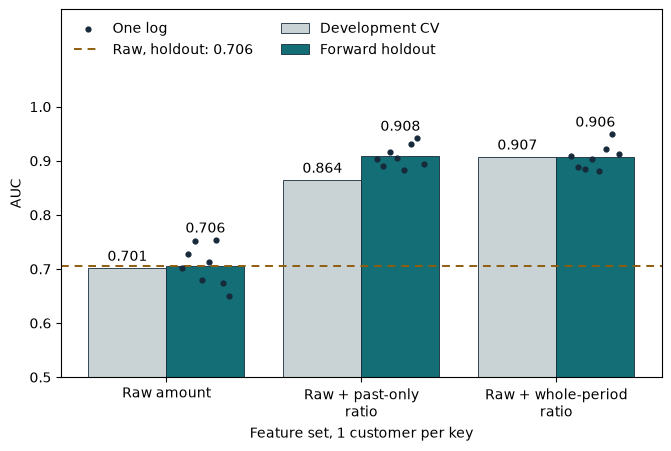

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch07 import draw, NCOLS, HEIGHT

DEFAULT = 1
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

With 1 customer per key, the raw amount scores 0.706 on the forward holdout and the past-only ratio 0.908: 0.908 - 0.706 = 0.202 of lift, so the past-only history is worth building at this key quality. In cross-validation the whole-period mean scores 0.043 above the past-only mean (0.907 against 0.864); on the holdout, where later rows do not exist, the difference is -0.002.

- Lift of the past-only ratio on the holdout: 0.908 - 0.706 = +0.202.
- Development advantage of the whole-period mean: 0.907 - 0.864 = +0.043.
- Holdout advantage of the whole-period mean: 0.906 - 0.908 = -0.002.
- Past-only ratio, cross-validation minus holdout: 0.864 - 0.908 = -0.044 (holdout rows have longer histories).

## Apply this to your competition

- Write down the prediction unit, the contextual entity and the history cutoff before building the feature.
- Count how many records each pseudo-ID key holds; a key that mixes many entities has a mean that describes none of them.
- Build histories from rows before the prediction time only, and test a whole-period mean only to see what it would falsely add.
- Keep the raw-amount baseline and compare the history feature against it on a later period, not on cross-validation alone.

Book location: Chapter 7, The Pattern: Find the Entity the Problem Is Really About.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)